# Disaster effects prediction and insight with NSF

**steps**:
- load the disaster dataset and feats dataset
- combine them
- make a dataset for each disaster type
- for each type (starting with only one):
    * standardize and normalize the features
    * define the NSF model
    * train the model
    * inspect the resulting distribution
    * see the conditioning features effects

**dataset design**:
- one dataframe per event type
- time reference feat as ...
- no topographical feat as coords, not state/county
- geographical and natural feats for conditioning
- casualties and damages as y 

#### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

In [2]:
DISASTER_DATA_DIR = Path("datasets")
COND_FEATS_PATH = Path("datasets/disasters_new_feats/all_new_feats.csv")

## Dataset Preparation

### Loading

In [3]:
disaster_df = utils.load_disaster_dataset(DISASTER_DATA_DIR)
feats_df = pd.read_csv(COND_FEATS_PATH)

In [4]:
print(disaster_df.columns)
print(feats_df.columns)

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'],
      dtype='str')
Index(['PRECIPITATION', 'TMIN', 'TMAX', 'BEGIN_LAT', 'BEGIN_LON', 'ELEVATION',
       'SLOPE', 'COV_BARREN', 'COV_CULTIVATED', 'COV_VEG

### Disaster processing

In [5]:
# reduce the disaster dataset to only the relevant columns
cols_to_keep = ["EVENT_TYPE", "BEGIN_DATE_TIME", "END_DATE_TIME", "INJURIES_DIRECT", "INJURIES_INDIRECT", "DEATHS_DIRECT",
                     "DEATHS_INDIRECT", "DAMAGE_PROPERTY", "DAMAGE_CROPS", "MAGNITUDE", "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON"] # "STATE", "FLOOD_CAUSE", "TOR_F_SCALE", "TOR_LENGTH", "TOR_WIDTH", "END_AZIMUTH", "END_LOCATION", 
disaster_df = disaster_df[cols_to_keep]

In [6]:
# remove unpredictable disaster types
unpredictable_events = ['High Surf', 'Sneakerwave', 'Seiche', 'Dense Smoke', 'Rip Current', 'Tropical Depression', 'Tsunami',
                    'Marine Tropical Depression', 'Volcanic Ashfall', 'Astronomical Low Tide', 'Dust Devil', 'Storm Surge/Tide']

disaster_df = disaster_df[~disaster_df['EVENT_TYPE'].isin(unpredictable_events)]

In [7]:
# aggregate events into broader categories
disaster_df['EVENT_GROUP'] = disaster_df['EVENT_TYPE'].replace(utils.disaster_events_group_map)
disaster_df.drop(columns=['EVENT_TYPE'], inplace=True)

In [8]:
# aggregate y cols into damages and casualties
disaster_df['DAMAGES'] = disaster_df['DAMAGE_PROPERTY'].apply(utils.damage_to_numeric) + disaster_df['DAMAGE_CROPS'].apply(utils.damage_to_numeric)
disaster_df['CASUALTIES'] = disaster_df['INJURIES_DIRECT'].fillna(0) + disaster_df['INJURIES_INDIRECT'].fillna(0) + disaster_df['DEATHS_DIRECT'].fillna(0) + disaster_df['DEATHS_INDIRECT'].fillna(0)

disaster_df.drop(columns=['DAMAGE_PROPERTY', 'DAMAGE_CROPS'], inplace=True)
disaster_df.drop(columns=['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT'], inplace=True)

In [9]:
# change END_DATE_TIME to duration in hours
disaster_df['END_DATE_TIME'] = pd.to_datetime(disaster_df['END_DATE_TIME'])
disaster_df['BEGIN_DATE_TIME'] = pd.to_datetime(disaster_df['BEGIN_DATE_TIME'])
disaster_df['DURATION_HOURS'] = (disaster_df['END_DATE_TIME'] - disaster_df['BEGIN_DATE_TIME']).dt.total_seconds() / 3600
disaster_df.drop(columns=['END_DATE_TIME'], inplace=True)

C:\Users\matti\AppData\Local\Temp\ipykernel_7724\2042865307.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  disaster_df['END_DATE_TIME'] = pd.to_datetime(disaster_df['END_DATE_TIME'])
C:\Users\matti\AppData\Local\Temp\ipykernel_7724\2042865307.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  disaster_df['BEGIN_DATE_TIME'] = pd.to_datetime(disaster_df['BEGIN_DATE_TIME'])


In [10]:
# split MAGNITUDE into HAIL_SIZE and WIND_SPEED
disaster_df['HAIL_SIZE'] = disaster_df['MAGNITUDE'].where(disaster_df['EVENT_GROUP'] == 'Hail', 0)
disaster_df['WIND_SPEED'] = disaster_df['MAGNITUDE'].where(disaster_df['EVENT_GROUP'] != 'Hail', 0)
disaster_df['WIND_SPEED'] = disaster_df['WIND_SPEED'].fillna(0)
disaster_df.drop(columns=['MAGNITUDE'], inplace=True)

In [11]:
# encode datetime
disaster_df['TIME_DAY_SIN'] = np.sin(2 * np.pi * disaster_df['BEGIN_DATE_TIME'].dt.dayofyear / 365.25)
disaster_df['TIME_DAY_COS'] = np.cos(2 * np.pi * disaster_df['BEGIN_DATE_TIME'].dt.dayofyear / 365.25)
disaster_df['TIME_YEAR_NORM'] = (disaster_df['BEGIN_DATE_TIME'].dt.year - disaster_df['BEGIN_DATE_TIME'].dt.year.min()) / (disaster_df['BEGIN_DATE_TIME'].dt.year.max() - disaster_df['BEGIN_DATE_TIME'].dt.year.min())
disaster_df.drop(columns=['BEGIN_DATE_TIME'], inplace=True)

In [12]:
# remove coords cols (already have them in the feats dataset)
disaster_df = disaster_df.drop(columns=["BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON"])

In [13]:
disaster_df.head()

,EVENT_GROUP,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,WIND_SPEED,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM
0,Heavy Rain,2000.0,0,0.0,0.0,0.0,-0.244772,-0.969581,0.0
1,Wind,0.0,0,0.0,0.0,50.0,-0.244772,-0.969581,0.0
2,Wind,0.0,0,0.0,0.0,50.0,-0.261414,-0.965227,0.0
3,Wind,0.0,0,0.0,0.0,50.0,-0.126528,-0.991963,0.0
4,Wind,0.0,0,0.0,0.0,60.0,-0.126528,-0.991963,0.0


### Merging

In [14]:
df = pd.merge(disaster_df, feats_df, left_index=True, right_index=True)
df.head()

,EVENT_GROUP,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,WIND_SPEED,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
0,Heavy Rain,2000.0,0,0.0,0.0,0.0,-0.244772,-0.969581,0.0,1133.73,...,5.62,0.0,0.157,0.039,0.708,0.012,0.0,0.085,1248.1,237.1
1,Wind,0.0,0,0.0,0.0,50.0,-0.244772,-0.969581,0.0,1144.69,...,6.52,0.0,0.173,0.048,0.702,0.007,0.0,0.070,528.2,236.5
2,Wind,0.0,0,0.0,0.0,50.0,-0.261414,-0.965227,0.0,1433.45,...,39.69,0.0,0.056,0.006,0.936,0.001,0.0,0.001,431.3,363.6
3,Wind,0.0,0,0.0,0.0,50.0,-0.126528,-0.991963,0.0,1442.06,...,11.47,0.0,0.379,0.023,0.527,0.069,0.0,0.001,842.2,462.1
4,Wind,0.0,0,0.0,0.0,60.0,-0.126528,-0.991963,0.0,1327.57,...,15.72,0.0,0.405,0.016,0.567,0.006,0.0,0.005,1563.3,457.8


### Splitting by event type

In [15]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [16]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [17]:
event_group_dfs['Hail'].head()

,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,TMIN,TMAX,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
65,0.0,0,0.0,1.00,0.154204,0.988039,0.0,1404.65,11.66,22.69,...,1.89,0.000,0.716,0.146,0.136,0.002,0.0,0.000,256.4,415.3
72,0.0,0,0.0,0.88,0.353445,0.935455,0.0,1519.92,12.85,24.73,...,6.01,0.003,0.120,0.047,0.769,0.040,0.0,0.021,1082.0,170.3
74,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1478.56,12.41,24.58,...,5.17,0.000,0.328,0.094,0.538,0.001,0.0,0.040,515.2,217.7
76,100.0,0,0.0,1.75,0.353445,0.935455,0.0,1589.20,12.37,24.92,...,7.35,0.000,0.049,0.020,0.930,0.001,0.0,0.000,925.4,142.4
82,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1437.68,12.31,24.38,...,4.94,0.000,0.183,0.119,0.467,0.018,0.0,0.212,377.5,223.6


## Model

In [67]:
df = event_group_dfs['Freeze']

### Data normalization and Dataset creation

In [68]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED',
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [69]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [70]:
# targets log transformation
Y = np.log1p(Y)

In [71]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

In [72]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


In [73]:
# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

In [74]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

### Model definition

In [149]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256

In [150]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

In [151]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

In [152]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

### Model training

In [153]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []
        
history = TrainingHistory()

best_val_loss = np.inf
for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        loss = -flow(x).log_prob(y).mean()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    flow.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    # Save history
    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]['lr'])
    
    print(
        f"Epoch {epoch:02d} | Time: {time.time() - t0:.2f}s : "
        f"Train NLL: {train_loss:.3f}, "
        f"Val NLL: {val_loss:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(flow.state_dict(), "./flow2_runs/best_flow.pt")

Epoch 00 | Time: 5.17s : Train NLL: -1.454, Val NLL: -3.908
Epoch 01 | Time: 6.36s : Train NLL: -3.830, Val NLL: -3.428
Epoch 02 | Time: 6.71s : Train NLL: -2.729, Val NLL: -5.014
Epoch 03 | Time: 6.16s : Train NLL: -4.345, Val NLL: -3.605
Epoch 04 | Time: 5.89s : Train NLL: -4.001, Val NLL: -4.895
Epoch 05 | Time: 6.01s : Train NLL: -3.533, Val NLL: -4.133
Epoch 06 | Time: 6.40s : Train NLL: -3.793, Val NLL: -4.453
Epoch 07 | Time: 7.03s : Train NLL: -4.254, Val NLL: -5.121
Epoch 08 | Time: 6.13s : Train NLL: -4.577, Val NLL: -3.197
Epoch 09 | Time: 6.08s : Train NLL: -5.045, Val NLL: -2.465
Epoch 10 | Time: 6.60s : Train NLL: -5.330, Val NLL: -5.137
Epoch 11 | Time: 6.74s : Train NLL: -2.215, Val NLL: -1.875
Epoch 12 | Time: 6.00s : Train NLL: -4.550, Val NLL: -4.530
Epoch 13 | Time: 6.42s : Train NLL: -4.240, Val NLL: -5.047
Epoch 14 | Time: 6.27s : Train NLL: -4.992, Val NLL: -2.704
Epoch 15 | Time: 6.19s : Train NLL: -4.178, Val NLL: -4.071
Epoch 16 | Time: 5.92s : Train NLL: -3.5

### Model Evaluation

In [154]:
flow.load_state_dict(torch.load("./flow2_runs/best_flow.pt"))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

C:\Users\matti\AppData\Local\Temp\ipykernel_7724\2846061307.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load("./flow2_runs/best_flow.pt"))

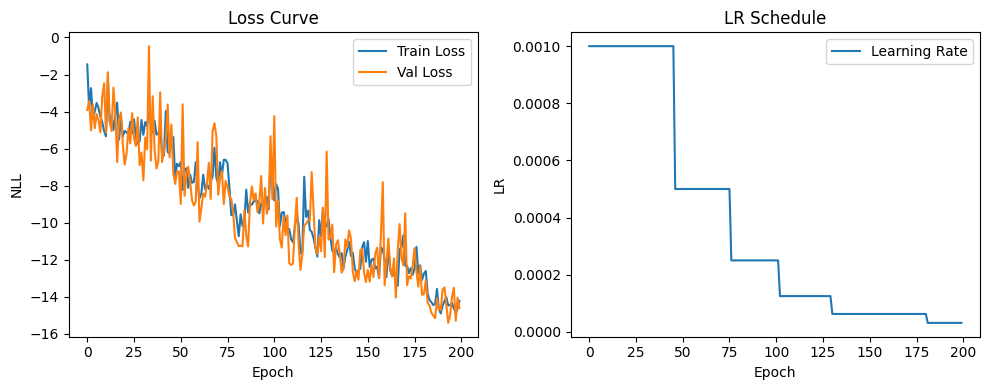

In [155]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


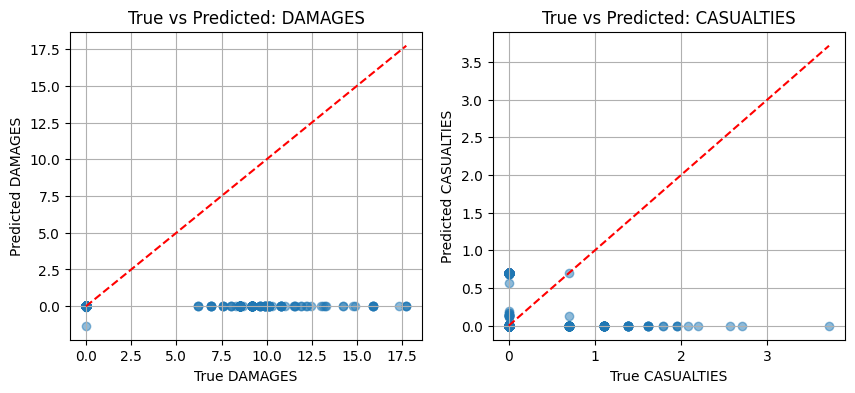

In [156]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

## Result Analysis

In [157]:
X_test = X_test.to(device)
Y_test = Y_test.to(device)
pass

### Metrics & statistics #1

Negative Log-Likelihood

In [158]:
with torch.no_grad():
    X = X_test.to(device)
    Y = Y_test.to(device)
    test_nll = -flow(X).log_prob(Y).mean().item()

print(f"Test NLL: {test_nll:.3f}")

Test NLL: -15.387


In [159]:
def sample_predictions(flow, X, n_samples=1000):
    samples = []
    with torch.no_grad():
        for x in X:
            dist = flow(x.unsqueeze(0))
            s = dist.sample((n_samples,))  # [S,1,2]
            samples.append(s.squeeze(1))
    return torch.stack(samples)  # [N,S,2]

In [160]:
# Draw Posterior Predictive Samples
pred_samples = sample_predictions(flow, X_test[:200], n_samples=500)

In [161]:
def invert_transform(samples):
    s = samples.reshape(-1,2).cpu().numpy()
    s = y_scaler.inverse_transform(s)
    s = np.expm1(s)
    return s.reshape(samples.shape)


In [162]:
# Undo Scaling and Log
pred_samples = invert_transform(pred_samples)
Y_true = invert_transform(Y_test[:200].unsqueeze(1)).squeeze(1)

#### Marginal Distribution Plots

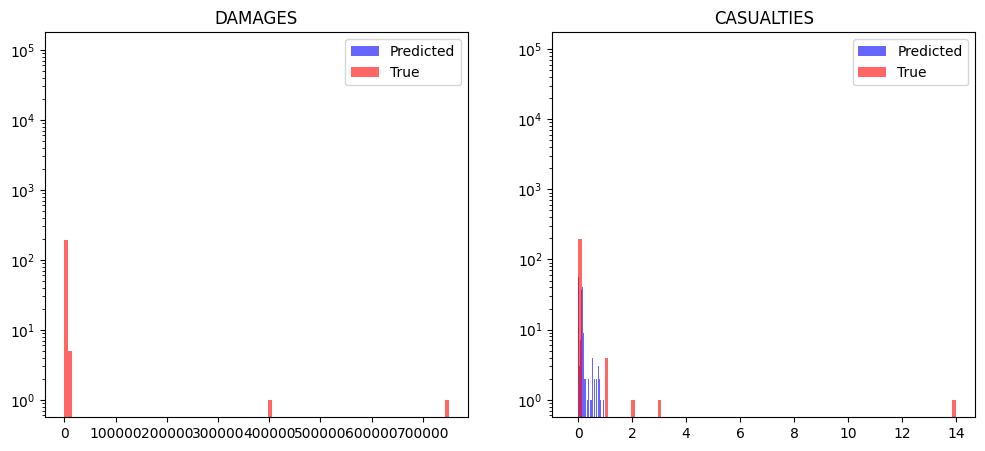

In [163]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(pred_samples[:,:,0].flatten(), bins=100, alpha=0.6, color='blue', label='Predicted')
plt.hist(Y_true[:,0], bins=100, alpha=0.6, color='red', label='True')
plt.yscale("log")
plt.title("DAMAGES")
plt.legend()

plt.subplot(1,2,2)
plt.hist(pred_samples[:,:,1].flatten(), bins=100, alpha=0.6, color='blue', label='Predicted')
plt.hist(Y_true[:,1], bins=100, alpha=0.6, color='red', label='True')
plt.yscale("log")
plt.title("CASUALTIES")
plt.legend()

plt.show()


#### Joint Distribution (Correlation)

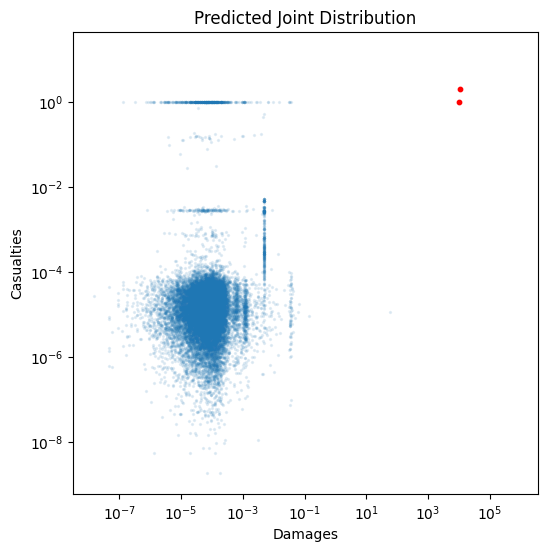

In [164]:
plt.figure(figsize=(6,6))
plt.scatter(
    pred_samples[:,:,0].flatten(),
    pred_samples[:,:,1].flatten(),
    s=2, alpha=0.1
)
plt.scatter(Y_true[:,0], Y_true[:,1], color="red", s=10)
plt.xlabel("Damages")
plt.ylabel("Casualties")
plt.xscale("log")
plt.yscale("log")
plt.title("Predicted Joint Distribution")
plt.show()


#### Coverage

In [165]:
lower = np.percentile(pred_samples, 5, axis=1)
upper = np.percentile(pred_samples, 95, axis=1)

inside = ((Y_true >= lower) & (Y_true <= upper))
coverage = inside.mean(axis=0)

print("90% coverage DAMAGES:", coverage[0])
print("90% coverage CASUALTIES:", coverage[1])


90% coverage DAMAGES: 0.935
90% coverage CASUALTIES: 0.965


#### Single-Event Posterior Plot

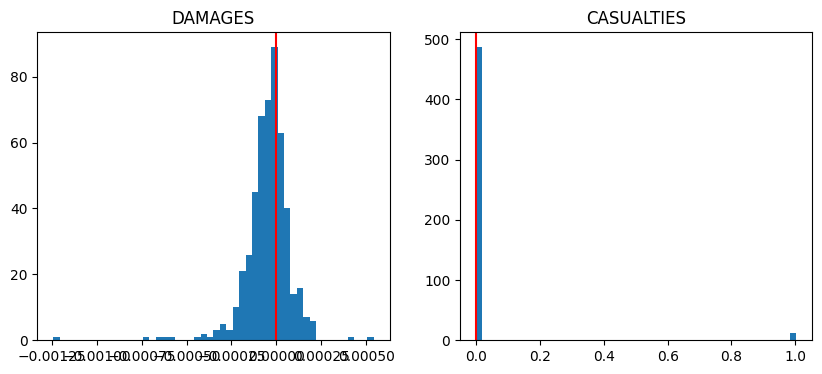

In [166]:
i = 5
s = pred_samples[i]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(s[:,0], bins=50)
plt.axvline(Y_true[i,0], color="red")
plt.title("DAMAGES")
plt.subplot(1,2,2)
plt.hist(s[:,1], bins=50)
plt.axvline(Y_true[i,1], color="red")
plt.title("CASUALTIES")
plt.show()


### Event simulation

In [167]:
custom_event = {
 'BEGIN_LAT': 35.0,
 'BEGIN_LON': -90.0,
 'DURATION_HOURS': 6,
 'WIND_SPEED': 40,
 'TIME_DAY_SIN': 0.5,
 'TIME_DAY_COS': 0.86,
 'TIME_YEAR_NORM': 0.7,
 'PRECIPITATION': 20,
 'TMIN': 15,
 'TMAX': 28,
 'ELEVATION': 200,
 'SLOPE': 3,
 'COV_BARREN': 0.05,
 'COV_CULTIVATED': 0.40,
 'COV_VEGETATION': 0.30,
 'COV_FOREST': 0.15,
 'COV_WATER': 0.02,
 'COV_SNOW_ICE': 0.00,
 'COV_URBAN': 0.08,
 'RIVER_DISTANCE': 1.5,
 'SEA_DISTANCE': 200
}

In [168]:
x_new = np.array([custom_event[c] for c in X_COLS]).reshape(1,-1)
x_new = x_scaler.transform(x_new)
x_new = torch.tensor(x_new, dtype=torch.float32).to(device)

with torch.no_grad():
    dist = flow(x_new)
    samples = dist.sample((5000,)).squeeze(1)

samples = invert_transform(samples)

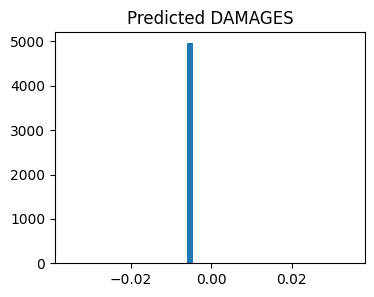

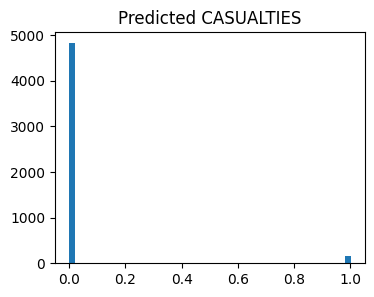

In [169]:
plt.figure(figsize=(4,3))
plt.hist(samples[:,0], bins=50)
plt.title("Predicted DAMAGES")
plt.show()

plt.figure(figsize=(4,3))
plt.hist(samples[:,1], bins=50)
plt.title("Predicted CASUALTIES")
plt.show()


In [170]:
print("Expected damages:", samples[:,0].mean())
print("Median damages:", np.median(samples[:,0]))
print("95% interval:", np.percentile(samples[:,0],[2.5,97.5]))

print("Expected casualties:", samples[:,1].mean())
print("Median casualties:", np.median(samples[:,1]))
print("95% interval:", np.percentile(samples[:,1],[2.5,97.5]))

Expected damages: -0.004916247
Median damages: -0.0048889797
95% interval: [-0.00543195 -0.00469441]
Expected casualties: 0.030991089
Median casualties: -8.281908e-05
95% interval: [-3.10062453e-04  9.99197584e-01]


#### Counterfactuals

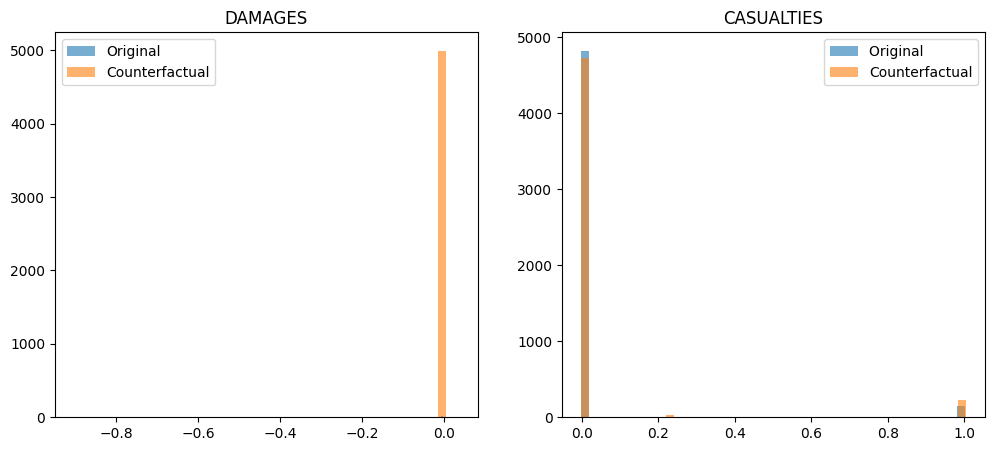

In [171]:
x_cf = x_new.clone()
idx = X_COLS.index("COV_URBAN")
x_cf[0,idx] = (0.5 - x_scaler.mean_[idx]) / x_scaler.scale_[idx]

# Sample again → compare distributions.
with torch.no_grad():
    dist_cf = flow(x_cf)
    samples_cf = dist_cf.sample((5000,)).squeeze(1)

samples_cf = invert_transform(samples_cf)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(samples[:,0], bins=50, alpha=0.6, label="Original")
plt.hist(samples_cf[:,0], bins=50, alpha=0.6, label="Counterfactual")
plt.title("DAMAGES")
plt.legend()
plt.subplot(1,2,2)
plt.hist(samples[:,1], bins=50, alpha=0.6, label="Original ")
plt.hist(samples_cf[:,1], bins=50, alpha=0.6, label="Counterfactual")
plt.title("CASUALTIES")
plt.legend()
plt.show()


### Metrics & statistics #2

In [172]:
def sample_predictive(flow, x, n=10000):
    """
    x: torch tensor shape (1, X_DIM)
    returns samples in original scale: (n,2)
    """
    with torch.no_grad():
        dist = flow(x)
        samples = dist.sample((n,)).squeeze(1).cpu().numpy()

    samples = y_scaler.inverse_transform(samples)
    samples = np.expm1(samples)
    return samples


In [173]:
# random test sample
idx = np.random.randint(len(X_test))
x0 = X_test[idx:idx+1].to(next(flow.parameters()).device)
y_true = Y_test[idx].cpu().numpy()
y_true = np.expm1(y_scaler.inverse_transform(y_true.reshape(1,-1)))[0]

samples = sample_predictive(flow, x0)


#### 1. Joint Distribution Visualization

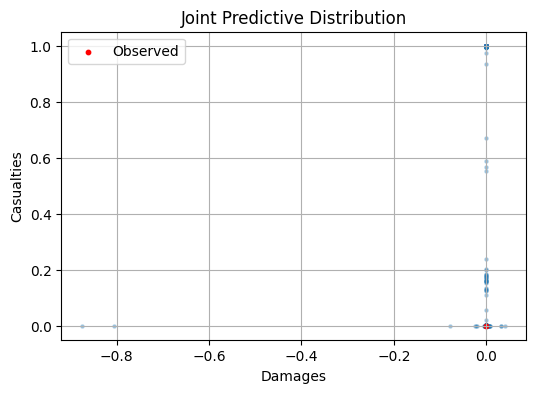

In [174]:
plt.figure(figsize=(6,4))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.3)
plt.scatter(y_true[0], y_true[1], color="red", s=10, label="Observed")
plt.xlabel("Damages")
plt.ylabel("Casualties")
plt.title("Joint Predictive Distribution")
plt.legend()
plt.grid()
plt.show()


#### 2. Marginal Distributions

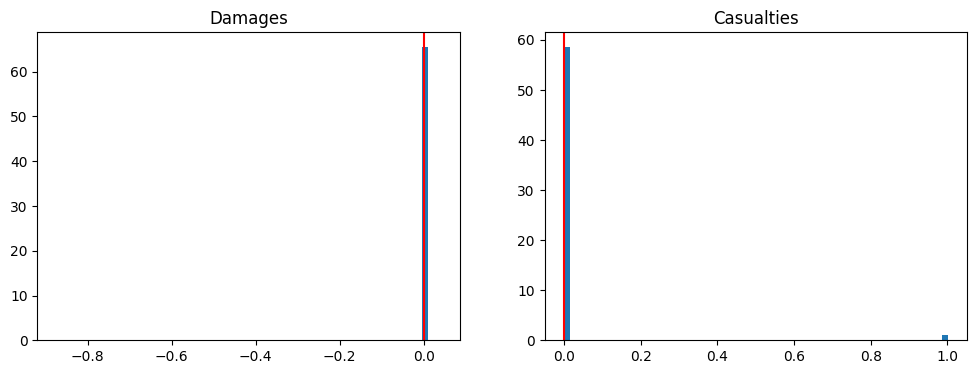

In [175]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(samples[:,0], bins=60, density=True)
axes[0].axvline(y_true[0], color="red")
axes[0].set_title("Damages")

axes[1].hist(samples[:,1], bins=60, density=True)
axes[1].axvline(y_true[1], color="red")
axes[1].set_title("Casualties")

plt.show()


#### 3. Output Correlation

In [176]:
corr = np.corrcoef(samples.T)[0,1]
print("Predicted correlation:", corr)


Predicted correlation: -0.0008946463252092317


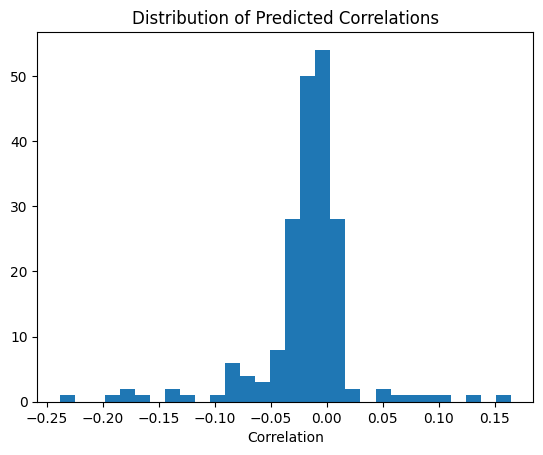

In [177]:
cors = []

for i in range(200):
    x = X_test[i:i+1].to(next(flow.parameters()).device)
    s = sample_predictive(flow, x, 1000)
    cors.append(np.corrcoef(s.T)[0,1])

plt.hist(cors, bins=30)
plt.xlabel("Correlation")
plt.title("Distribution of Predicted Correlations")
plt.show()


#### 4. Partial Dependence Plot (Single Feature)

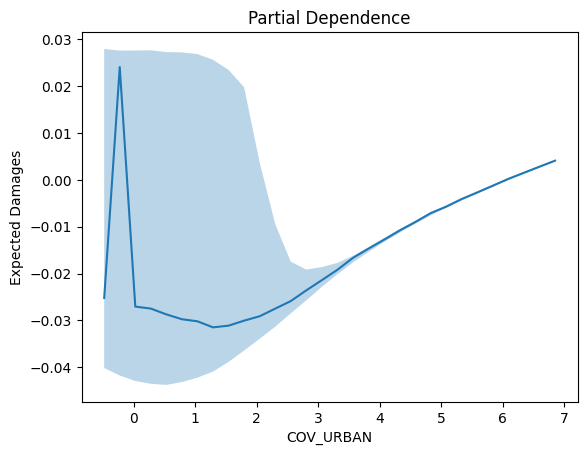

In [178]:
feature = "COV_URBAN"
k = X_COLS.index(feature)

grid = np.linspace(
    X_train[:,k].min(),
    X_train[:,k].max(),
    30
)

base = X_test.mean(0, keepdim=True)

means = []
q05 = []
q95 = []

for g in grid:
    x = base.clone()
    x[0,k] = g
    s = sample_predictive(flow, x.to(next(flow.parameters()).device))
    means.append(s[:,0].mean())
    q05.append(np.percentile(s[:,0],5))
    q95.append(np.percentile(s[:,0],95))

plt.plot(grid, means)
plt.fill_between(grid, q05, q95, alpha=0.3)
plt.xlabel(feature)
plt.ylabel("Expected Damages")
plt.title("Partial Dependence")
plt.show()


#### 5. ICE Curves (Heterogeneous Effects)

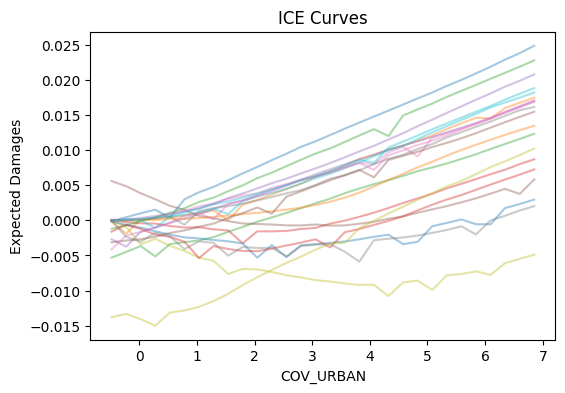

In [179]:
plt.figure(figsize=(6,4))

for i in range(20):
    base = X_test[i:i+1].clone()
    curve = []

    for g in grid:
        x = base.clone()
        x[0,k] = g
        s = sample_predictive(flow, x.to(next(flow.parameters()).device), 500)
        curve.append(s[:,0].mean())

    plt.plot(grid, curve, alpha=0.4)

plt.xlabel(feature)
plt.ylabel("Expected Damages")
plt.title("ICE Curves")
plt.show()


#### 6. Counterfactual Location Comparison

In [180]:
x = X_test[10:11].clone()

urban_low = -2.0
urban_high = 2.0

x_low = x.clone()
x_high = x.clone()

x_low[0,k] = urban_low
x_high[0,k] = urban_high

s_low = sample_predictive(flow, x_low.to(next(flow.parameters()).device))
s_high = sample_predictive(flow, x_high.to(next(flow.parameters()).device))


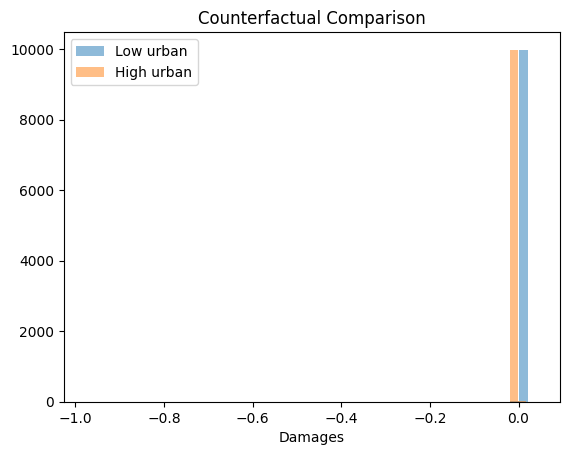

In [181]:
plt.hist(s_low[:,0], bins=50, alpha=0.5, label="Low urban")
plt.hist(s_high[:,0], bins=50, alpha=0.5, label="High urban")
plt.legend()
plt.xlabel("Damages")
plt.title("Counterfactual Comparison")
plt.show()


#### 7. Permutation Feature Importance

In [182]:
def permutation_importance(flow, X, Y, feature_index, n=500):
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]

    with torch.no_grad():
        base = -flow(Xp).log_prob(Yp).mean().item()

    Xp[:,feature_index] = Xp[torch.randperm(len(Xp)),feature_index]

    with torch.no_grad():
        perm = -flow(Xp).log_prob(Yp).mean().item()

    return perm - base


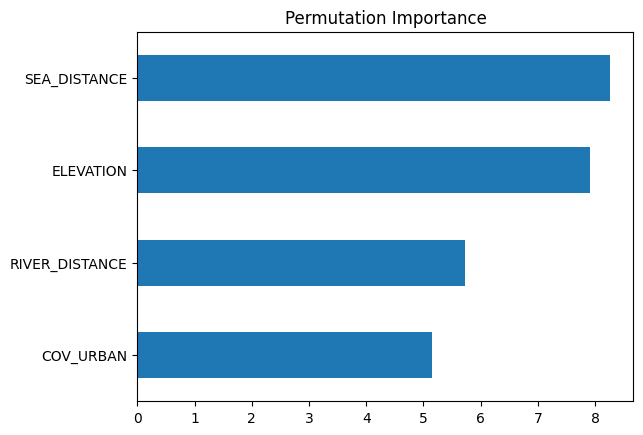

In [183]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test = X_test.to(device)
Y_test = Y_test.to(device)

importances = {}

for f in ["COV_URBAN","ELEVATION","RIVER_DISTANCE","SEA_DISTANCE"]:
    k = X_COLS.index(f)
    importances[f] = permutation_importance(flow, X_test, Y_test, k)

pd.Series(importances).sort_values().plot.barh()
plt.title("Permutation Importance")
plt.show()


#### 8. Calibration / Coverage

In [184]:
def coverage(flow, X, Y, q=90):
    inside = []
    for i in range(200):
        x = X[i:i+1].to(next(flow.parameters()).device)
        s = sample_predictive(flow, x, 2000)
        lo = np.percentile(s, (100-q)/2, axis=0)
        hi = np.percentile(s, 100-(100-q)/2, axis=0)

        y = Y[i].cpu().numpy()
        y = np.expm1(y_scaler.inverse_transform(y.reshape(1,-1)))[0]

        inside.append(np.all((y>=lo)&(y<=hi)))
    return np.mean(inside)


In [185]:
print("90% interval coverage:", coverage(flow, X_test, Y_test))

90% interval coverage: 0.91
